In [6]:
import trimesh
import numpy as np
import scipy.ndimage
import os

def stl_to_voxel(file_path, pitch=1.0):
    """
    Convert STL mesh to voxel grid using Trimesh.
    :param file_path: path to STL file
    :param pitch: voxel size (smaller = higher resolution)
    :return: binary voxel grid (numpy array)
    """
    mesh = trimesh.load(file_path)
    if not isinstance(mesh, trimesh.Trimesh):
        raise ValueError(f"{file_path} does not contain a valid Trimesh object")
    
    # Ensure the mesh is watertight
    if not mesh.is_watertight:
        mesh.fill_holes()  # fix: do NOT assign this back

    # Voxelize
    vox = mesh.voxelized(pitch)
    return vox.matrix.astype(np.uint8)



In [7]:
def resize_voxel(voxel_grid, target_shape=(64, 64, 64)):
    """
    Resize voxel grid to fixed target shape using interpolation.
    :param voxel_grid: numpy array of shape (D, H, W)
    :param target_shape: target shape (D, H, W)
    :return: resized voxel grid (float32)
    """
    zoom_factors = [t / s for t, s in zip(target_shape, voxel_grid.shape)]
    resized = scipy.ndimage.zoom(voxel_grid, zoom=zoom_factors, order=1)
    return (resized > 0.5).astype(np.uint8)

In [8]:
def process_and_save_stl_to_voxel(input_path, output_path, pitch=1.0, target_shape=(64, 64, 64)):
    """
    Convert an STL file to a resized voxel grid and save as a .npy file.
    """
    voxel = stl_to_voxel(input_path, pitch=pitch)
    voxel_resized = resize_voxel(voxel, target_shape)
    np.save(output_path, voxel_resized)
    print(f"Saved voxel grid to {output_path}, shape: {voxel_resized.shape}")


In [9]:
stl_path = "../data/processed/002/model/left.stl"  # change to your STL file
output_npy = "./voxel_002_left.npy"
process_and_save_stl_to_voxel(stl_path, output_npy, pitch=1.0, target_shape=(64, 64, 64))

Saved voxel grid to ./voxel_002_left.npy, shape: (64, 64, 64)


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_voxel(voxel_grid, threshold=0.5):
    """
    Visualize a 3D voxel grid using matplotlib.
    :param voxel_grid: 3D numpy array (binary)
    :param threshold: occupancy threshold for display
    """
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Get coordinates of voxels above threshold
    filled = voxel_grid > threshold
    x, y, z = filled.nonzero()

    ax.scatter(x, y, z, zdir='z', c='black', marker='s', s=50, alpha=0.1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title("Voxelized STL Visualization")
    plt.tight_layout()
    plt.show()


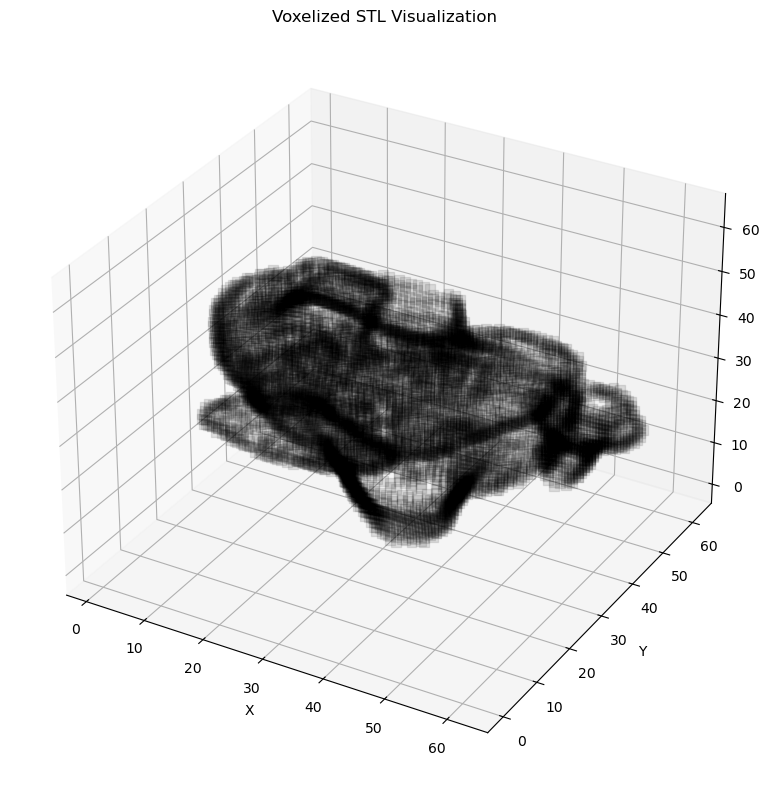

In [31]:
voxel = np.load("./voxel_002_left.npy")
visualize_voxel(voxel)


In [7]:
import trimesh
import numpy as np
import open3d as o3d

# Load the STL file
mesh = trimesh.load('../data/processed/002/model/left.stl')

# Create voxel grid from mesh
voxel_size = 1.0  # Adjust voxel size for resolution
voxelized = mesh.voxelized(pitch=voxel_size)

# Fill internal voxels
filled_voxelized = voxelized.fill()

# Extract filled voxel centers
voxel_points = filled_voxelized.points

# Convert to Open3D PointCloud for visualization
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(voxel_points)

voxel_geometry = o3d.geometry.VoxelGrid()
voxel_geometry = o3d.geometry.VoxelGrid.create_from_point_cloud(pcd, voxel_size=voxel_size)
o3d.visualization.draw_geometries([voxel_geometry])


In [4]:
print("Is watertight:", mesh.is_watertight)


Is watertight: True


In [ ]:
import trimesh
import numpy as np
import open3d as o3d
import random

# Load the STL mesh
mesh = trimesh.load('../data/processed/002/model/left.stl')

# Split mesh into connected components (isolated bones)
components = mesh.split(only_watertight=False)

print(f"Found {len(components)} components.")

# Parameters
voxel_size = 1.0  # adjust resolution as needed

# Prepare list to store point clouds
pcd_list = []

# Generate a random color for each component
for comp in components:
    # Voxelize and fill each component
    voxelized = comp.voxelized(pitch=voxel_size).fill()
    
    # Get voxel centers
    voxel_points = voxelized.points
    
    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(voxel_points)
    
    # Assign a random color to all points in this component
    color = np.random.rand(3)
    colors = np.tile(color, (len(voxel_points), 1))
    pcd.colors = o3d.utility.Vector3dVector(colors)
    
    pcd_list.append(pcd)

# Visualize all components with different colors
o3d.visualization.draw_geometries(pcd_list)


Found 4 components.


KeyboardInterrupt: 

In [45]:
import numpy as np
import open3d as o3d

# Load the npz file
data = np.load('../data/processed/002/model_separated/right/bone_7.npz')

# List all arrays inside npz
print("Arrays in npz:", list(data.keys()))

# Replace 'array_name' with the actual array name you want to visualize
volume = data['voxel']
assert volume.ndim == 3
print("Target shape:", volume.shape)

# Threshold to extract points
threshold = volume.mean()  # or choose a fixed value
voxels = np.argwhere(volume > threshold)
points = voxels.astype(float)

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Visualize
o3d.visualization.draw_geometries([pcd])


Arrays in npz: ['voxel']
Target shape: (128, 128, 128)


In [16]:
import numpy as np
from scipy.ndimage import zoom

def resize_and_pad(voxel, target_shape=(128, 128, 128)):
    original_shape = voxel.shape
    scale = min(t / o for t, o in zip(target_shape, original_shape))  # uniform scale to fit inside

    # Resize with preserved aspect ratio
    new_shape = tuple([int(round(o * scale)) for o in original_shape])
    resampled = zoom(voxel, zoom=[n/o for n, o in zip(new_shape, original_shape)], order=1)

    # Pad to 128×128×128
    pad_widths = []
    for res_size, target_size in zip(resampled.shape, target_shape):
        total_pad = target_size - res_size
        before = total_pad // 2
        after = total_pad - before
        pad_widths.append((before, after))

    padded = np.pad(resampled, pad_widths, mode='constant', constant_values=0)
    return padded

# Example usage
data = np.load("../data/processed/006/model/left.npz")
voxel = data["voxel"]
processed_voxel = resize_and_pad(voxel)

print("Final shape:", processed_voxel.shape)  # (128, 128, 128)


Final shape: (128, 128, 128)


In [19]:
# Threshold to extract points
threshold = processed_voxel.mean()  # or choose a fixed value
voxels = np.argwhere(processed_voxel > threshold)
points = voxels.astype(float)

# Create Open3D point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Visualize
o3d.visualization.draw_geometries([pcd])

In [31]:
from PIL import Image
import os

def check_image_resolution(image_path):
    if not os.path.exists(image_path):
        print(f"File not found: {image_path}")
        return

    try:
        with Image.open(image_path) as img:
            width, height = img.size
            print(f"Image: {image_path}")
            print(f"Resolution: {width} x {height}")
    except Exception as e:
        print(f"Error reading image: {e}")

# Example usage
check_image_resolution("../data/processed/z035/DRR/left/pa.png")


Image: ../data/processed/z035/DRR/left/pa.png
Resolution: 512 x 512


In [98]:
import numpy as np

volume = np.load('../output/knee_voxel_2.npy')
print("Original shape:", volume.shape)

# Remove batch dimension if present
if volume.shape[0] == 1:
    volume = np.squeeze(volume, axis=0)

assert volume.ndim == 3
print("Squeezed shape:", volume.shape)

# Continue as usual
threshold = volume.mean()
voxels = np.argwhere(volume > threshold)
points = voxels.astype(float)

import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

o3d.visualization.draw_geometries([pcd])


Original shape: (128, 128, 128)
Squeezed shape: (128, 128, 128)
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [95]:
import numpy as np
import open3d as o3d
from skimage import measure

# Load the 3D volume
volume = np.load('../output/knee_voxel_2.npy')
print("Original shape:", volume.shape)

# Remove batch dimension if present
if volume.shape[0] == 1:
    volume = np.squeeze(volume, axis=0)

assert volume.ndim == 3
print("Squeezed shape:", volume.shape)

# Normalize volume to [0, 1]
volume = (volume - volume.min()) / (volume.max() - volume.min())

# Use marching cubes to get surface mesh
threshold = 0.5  # Can be tuned, around the normalized mid-point
verts, faces, normals, _ = measure.marching_cubes(volume, level=threshold)

# Create Open3D triangle mesh
mesh = o3d.geometry.TriangleMesh()
mesh.vertices = o3d.utility.Vector3dVector(verts)
mesh.triangles = o3d.utility.Vector3iVector(faces)
mesh.vertex_normals = o3d.utility.Vector3dVector(normals)

# Optionally: set color, smooth shading
mesh.paint_uniform_color([0.9, 0.9, 0.9])
mesh.compute_vertex_normals()

# Visualize
o3d.visualization.draw_geometries([mesh])


ModuleNotFoundError: No module named 'skimage'